In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42); np.random.seed(42)

In [2]:
# loading dataset
df = pd.read_csv('../data/processed/dataset_long_pruned.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
dates   = sorted(df['datetime'].dt.date.unique())

FOLDS = [
    {'name': 'Fold 1', 'train': dates[:9],  'val': dates[9:11]},
    {'name': 'Fold 2', 'train': dates[:10], 'val': dates[10:12]},
]
FEATURE_COLS = [
    'iv_roll_mean_10',
    'iv_roll_mean_5',
    'iv_neighbor_mean',
    'wide_iv_neighbor_mean',
    'strike',
    'iv_neighbor_+1',
    'iv_neighbor_-1',
    'iv_neighbor_+2',
    'iv_neighbor_-2',
    'dist_from_atm_pct',
    'moneyness',
    'log_moneyness'
]

def make_holdout(val_df):

    np.random.seed(42)

    available_rows = val_df[val_df['iv'].notna()].index
    hidden_rows = np.random.choice(available_rows, size=int(0.2*len(available_rows)), replace=False)

    ground_truth =  val_df.loc[hidden_rows,'iv'].values

    val_masked = val_df.copy()
    val_masked.loc[hidden_rows,'iv'] = np.nan

    return val_masked, hidden_rows, ground_truth

In [3]:
# MLP Architecture
class IVSurfaceMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=[128, 64, 32], dropout=0.1):
        super().__init__()
        layers = []; prev = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.GELU(),
                nn.Dropout(dropout)
            ]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

model_test = IVSurfaceMLP(10)
n_params = sum(p.numel() for p in model_test.parameters())
print(f'MLP parameters: {n_params:,}')
print(model_test)

MLP parameters: 12,225
IVSurfaceMLP(
  (net): Sequential(
    (0): Linear(in_features=10, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): GELU(approximate='none')
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [4]:
# Training and predicting pipeline
def train_mlp(X_train, y_train, X_val, y_val, epochs=500, batch_size=256, patience=40):

    scaler  = StandardScaler()
    X_train_trf  = scaler.fit_transform(X_train)
    X_val_trf  = scaler.transform(X_val)

    Xtt = torch.tensor(X_train_trf, dtype=torch.float32)
    ytt = torch.tensor(y_train,   dtype=torch.float32)
    Xvt = torch.tensor(X_val_trf, dtype=torch.float32)
    yvt = torch.tensor(y_val,   dtype=torch.float32)

    loader  = DataLoader(TensorDataset(Xtt, ytt), batch_size=batch_size, shuffle=True)
    model   = IVSurfaceMLP(X_train.shape[1])
    opt     = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-5)
    sched   = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    loss_fn = nn.MSELoss()

    best_loss, best_state, no_imp = float('inf'), None, 0
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train(); epoch_loss = 0
        for xb, yb in loader:
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
            opt.step()
            epoch_loss += loss.item()
        sched.step()
        model.eval()
        with torch.no_grad():
            vl = loss_fn(model(Xvt), yvt).item()
        train_losses.append(epoch_loss / len(loader))
        val_losses.append(vl)
        if vl < best_loss:
            best_loss = vl
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1
            if no_imp >= patience: break

    model.load_state_dict(best_state)
    return model, scaler, epoch - patience, train_losses, val_losses

def predict_mlp(model, scaler, X):
    model.eval()
    with torch.no_grad():
        return model(torch.tensor(scaler.transform(X), dtype=torch.float32)).numpy()

In [5]:
fold_mses = []; all_losses = []
for fold in FOLDS:
    train_df = df[df['datetime'].dt.date.isin(fold['train'])].copy()
    val_df   = df[df['datetime'].dt.date.isin(fold['val'])].copy()

    val_masked, hidden_rows, ground_truth = make_holdout(val_df)

    train_obs   = train_df[train_df['iv'].notna()]
    X_all = train_obs[FEATURE_COLS].fillna(0).values
    y_all = train_obs['iv'].values

    model, scaler, best_ep, train_losses, val_losses = train_mlp(X_all[:int(0.85 * len(X_all))], y_all[:int(0.85 * len(X_all))], X_all[int(0.85 * len(X_all)):], y_all[int(0.85 * len(X_all)):])

    X_pred = val_masked.loc[hidden_rows, FEATURE_COLS].fillna(0).values
    preds  = predict_mlp(model, scaler, X_pred)

    mse    = mean_squared_error(ground_truth, preds)

    fold_mses.append(mse)
    all_losses.append((train_losses, val_losses, best_ep))
    
    print(f"  {fold['name']}: MSE={mse:.6f}  best_epoch={best_ep}")

mlp_mse = np.mean(fold_mses)
print(f"MLP MSE : {mlp_mse:.6f}")

  Fold 1: MSE=0.000037  best_epoch=140
  Fold 2: MSE=0.000017  best_epoch=157
MLP MSE : 0.000027


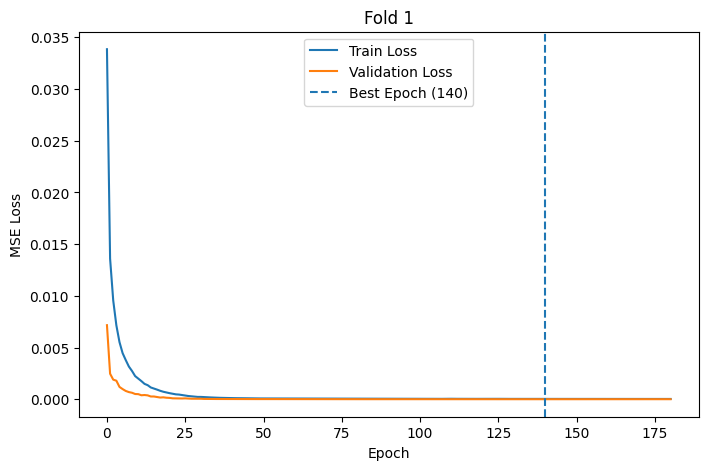

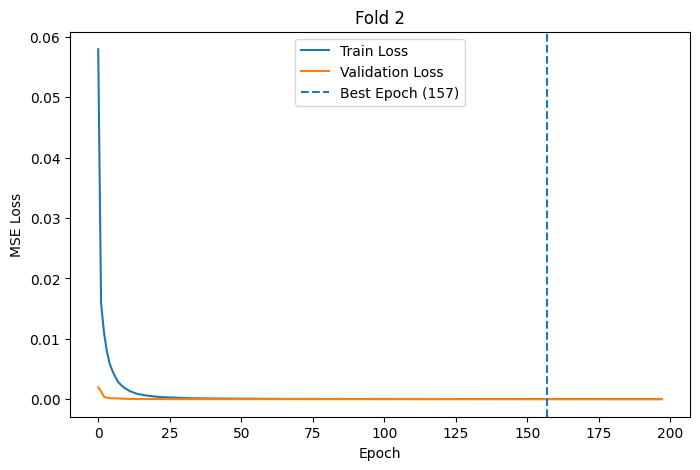

In [6]:
import matplotlib.pyplot as plt

for i, (train_losses, val_losses, best_ep) in enumerate(all_losses):

    plt.figure(figsize=(8,5))

    plt.plot(
        train_losses,
        label='Train Loss'
    )

    plt.plot(
        val_losses,
        label='Validation Loss'
    )

    plt.axvline(
        best_ep,
        linestyle='--',
        label=f'Best Epoch ({best_ep})'
    )

    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title(f'Fold {i+1}')
    plt.legend()

    plt.show()